# 03 — Segmentation K-Means
Entrée : `data/clean.csv`  →  Modèles : `models/kmeans.pkl`, `models/scaler_seg.pkl`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

BASE       = Path('d:/Smart-Free_GestionMess+Feedback/Smart-Free_GestionMess/ml-service')
MODELS_DIR = BASE / 'models'
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(BASE / 'data' / 'clean.csv')
print('Shape :', df.shape)
df.head(2)

Shape : (8871, 14)


,projectId,job_title,job_description,tags,client_state,client_country,client_average_rating,client_review_count,min_price,max_price,avg_price,currency,rate_type,tags_clean
0,37426471,development and implementation of a federated ...,please bid only if you are ready to do the wor...,"['algorithm', 'java', 'python', 'machine learn...",Heilbronn,Germany,5.0,17,8.0,30.0,19.0,EUR,fixed,"algorithm,java,python,machine learning (ml),fl..."
1,37421546,Data Entry -- 2,Project Title: Data Entry - Data Analysis in E...,"['excel', 'statistical analysis', 'statistics'...",Nagpur,India,0.0,0,750.0,1250.0,1000.0,INR,hourly,"excel,statistical analysis,statistics,spss sta..."


In [4]:
SEG_FEATURES = ['avg_price', 'client_average_rating', 'client_review_count']
X_seg = df[SEG_FEATURES].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)
print('X_scaled shape :', X_scaled.shape)

X_scaled shape : (8871, 3)


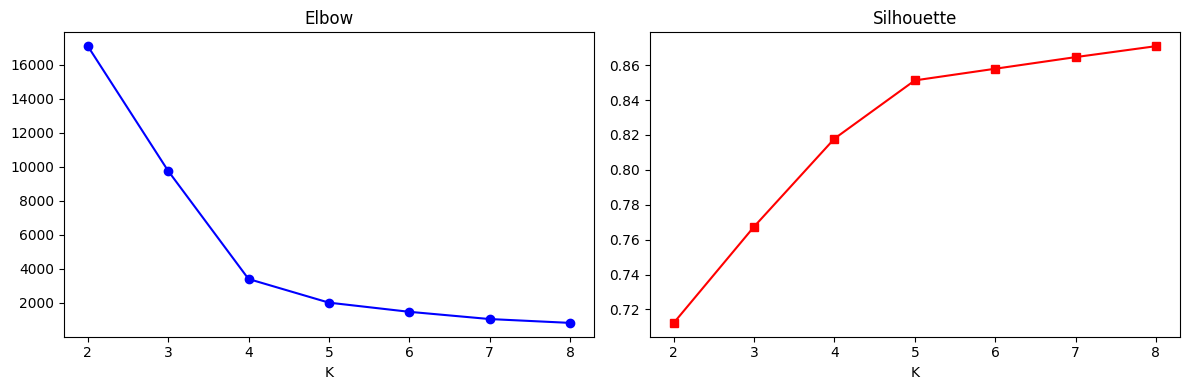

In [5]:
# Méthode du coude
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-'); ax1.set_title('Elbow'); ax1.set_xlabel('K')
ax2.plot(K_range, silhouettes, 'rs-'); ax2.set_title('Silhouette'); ax2.set_xlabel('K')
plt.tight_layout(); plt.show()

In [6]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)
print(f'Silhouette K=4 : {silhouette_score(X_scaled, df["segment"]):.3f}')
df.groupby('segment')[SEG_FEATURES].mean().round(2)

Silhouette K=4 : 0.818


,avg_price,client_average_rating,client_review_count
segment,,,
0,2485.55,0.00,0.00
1,1115.86,4.94,19.33
2,43.57,4.86,593.27
3,81895.83,1.02,2.61


In [7]:
seg_budget = df.groupby('segment')['avg_price'].mean().sort_values()
LABELS = {seg_budget.index[0]: 'Low-Budget',
          seg_budget.index[1]: 'Mid-Budget',
          seg_budget.index[2]: 'High-Budget',
          seg_budget.index[3]: 'Premium'}
df['segment_label'] = df['segment'].map(LABELS)
print(df['segment_label'].value_counts())

segment_label
High-Budget    4404
Mid-Budget     4135
Low-Budget      182
Premium         150
Name: count, dtype: int64


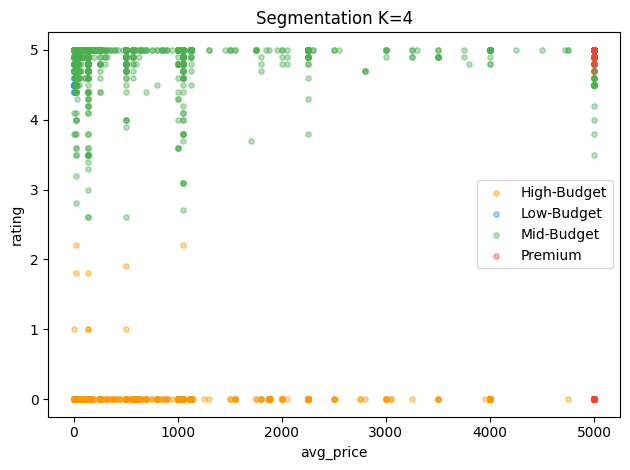

In [8]:
colors = {'Low-Budget':'#2196F3','Mid-Budget':'#4CAF50','High-Budget':'#FF9800','Premium':'#F44336'}
for label, grp in df.groupby('segment_label'):
    plt.scatter(grp['avg_price'].clip(upper=5000), grp['client_average_rating'],
                label=label, alpha=0.4, s=15, color=colors[label])
plt.xlabel('avg_price'); plt.ylabel('rating'); plt.title('Segmentation K=4')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
joblib.dump(kmeans, MODELS_DIR / 'kmeans.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler_seg.pkl')
df.to_csv(BASE / 'data' / 'segmented.csv', index=False)
print('Sauvegardés → models/kmeans.pkl  models/scaler_seg.pkl  data/segmented.csv')

Sauvegardés → models/kmeans.pkl  models/scaler_seg.pkl  data/segmented.csv
